# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
from PIL import Image, ImageOps
import numpy as np

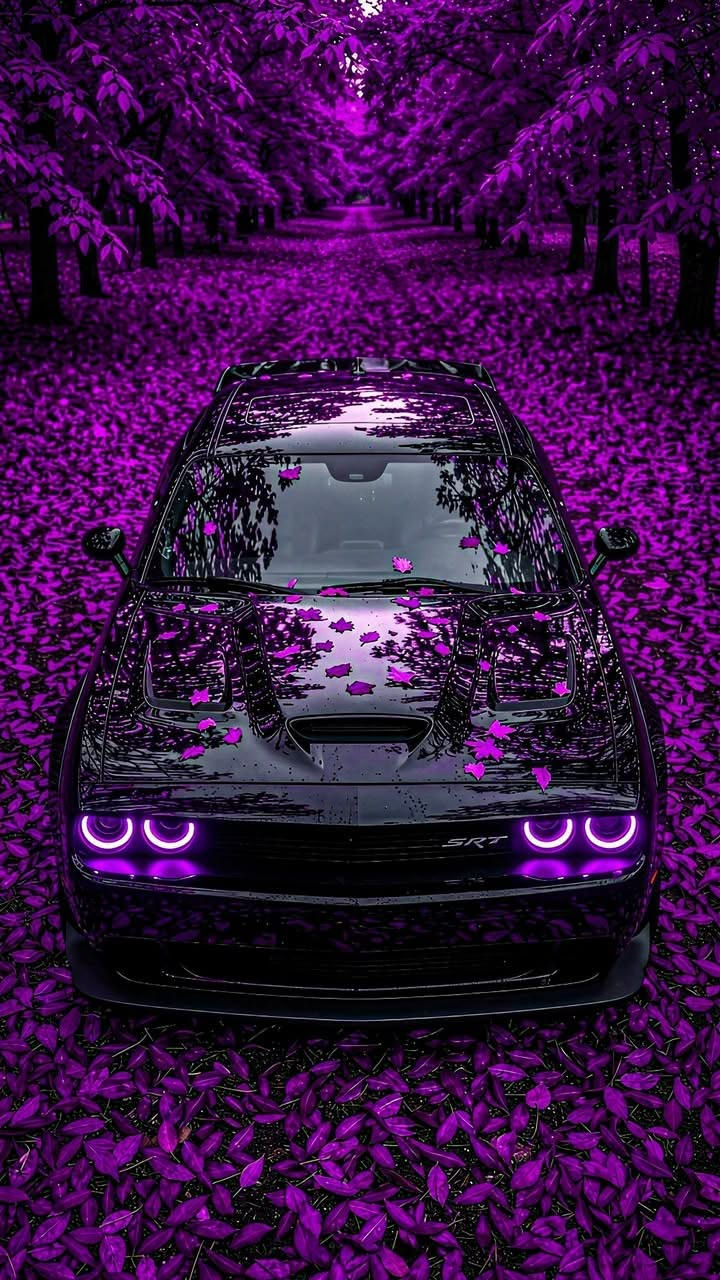

In [3]:
# ── Load image ────────────────────────────────────
img = Image.open("image.jpg")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [ ]:
# ── 1. Increase size (scale ×2) ────────────────────

width, height = img.size

new_width = width * 2
new_height = height * 2

scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

scaled_img

In [ ]:

# Save the scaled image and print the sizes
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [ ]:
# ── 2. Non-uniform scale (cx=2, cy=1) ─────────────

cx = 2
cy = 1

non_uniform_img = img.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

non_uniform_img

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [ ]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(120, expand=True)

rotated_img

In [ ]:
# Save the rotated image
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

### 3. Shear

In [ ]:
# -- c. Get the image dimensions ────────────────────

width, height = img.size

print("Width:", width)
print("Height:", height)

In [ ]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shear_matrix = (
    1, shear_factor, 0,
    0, 1, 0
)

In [ ]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_img = img.transform(
    img.size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

sheared_img

In [ ]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [ ]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array)

negative_img



In [ ]:
# Method 2: PIL's ImageOps

negative_img2 = ImageOps.invert(img.convert("RGB"))

negative_img2

In [ ]:
# ── 2. Log transformation ──────────────────────────

# Calculate c
c = 255 / np.log(1 + 255)

# Convert image to NumPy array
img_array = np.array(img).astype(float)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)

# Convert back to uint8 and PIL image
log_img = Image.fromarray(log_array.astype(np.uint8))

log_img

In [ ]:

# ── 3. Power-law / Gamma correction ───────────────

gamma = 0.5

img_array = np.array(img).astype(float) / 255.0

gamma_array = 255 * (img_array ** gamma)

gamma_img = Image.fromarray(gamma_array.astype(np.uint8))

gamma_img